# Validacion del modelo: mapa tonotopico y ganancia activa/pasiva

Reproduce, con pocos comandos, las dos validaciones ya cerradas:
- **Mapa tonotopico** vs. Greenwood (1990) / Liberman (1982), gato y humano a la vez.
- **Ganancia activa/pasiva** vs. las cifras textuales de Neely & Kim (1986).

In [1]:
import numpy as np
from cochleasim.models.params_loader import CAT_PARAMS, HUMAN_PARAMS
from cochleasim.analysis.response import compute_response_grid, tonotopic_map, gain_active_vs_passive
from cochleasim.validation.reference import load_greenwood_curve, load_gain_reference
from cochleasim.validation.compare import compare_curves

## 1. Mapa tonotopico -- gato y humano, superpuestos

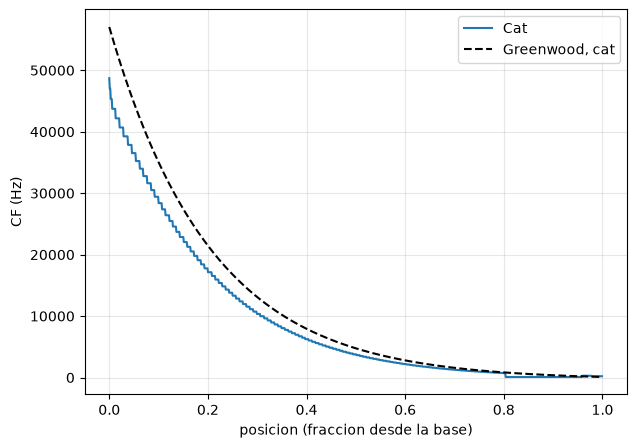

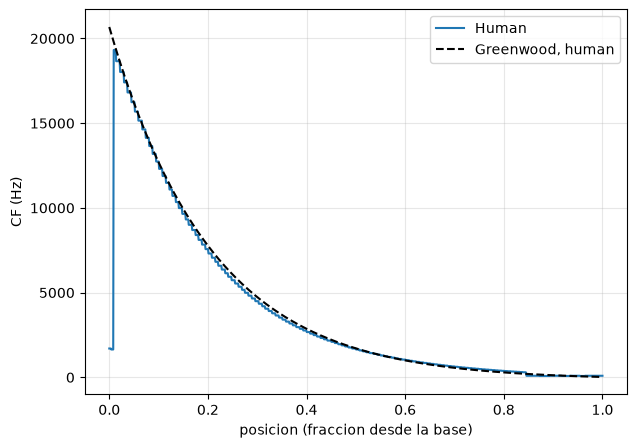

In [2]:
configs = {
    'Cat':   (CAT_PARAMS,   np.logspace(np.log10(50), np.log10(65000), 200), 'cat'),
    'Human': (HUMAN_PARAMS, np.logspace(np.log10(20), np.log10(20000), 200), 'human'),
}

for name, (params, freqs, species) in configs.items():
    x_cm, cf_hz = tonotopic_map(compute_response_grid(params, freqs, N=1000))
    valid = ~np.isnan(cf_hz)
    result = compare_curves({name: (x_cm[valid] / params.L, cf_hz[valid])}, load_greenwood_curve(species))
    result.plot(xlabel='posicion (fraccion desde la base)', ylabel='CF (Hz)')

### Error cuantitativo, 150 Hz-16 kHz
Rango elegido porque fuera de el la comparacion deja de ser fiable (cerca del apice el pico se acerca al borde del barrido de frecuencia; ver discusion en el capitulo 6 sobre la limitacion estructural del gato, reconocida por los propios Neely & Kim en su Fig. 9).

In [4]:
for name, (params, freqs, species) in configs.items():
    x_cm, cf_hz = tonotopic_map(compute_response_grid(params, freqs, N=1000))
    valid = ~np.isnan(cf_hz)
    result = compare_curves({name: (x_cm[valid] / params.L, cf_hz[valid])}, load_greenwood_curve(species))
    errs = [abs(row['error']) for row in result.summary_table() if 150 <= row['reference_y'] <= 16000]
    print(f'{name}: mediana = {np.median(errs):.1f}%  (n={len(errs)})')

Cat: mediana = 21.2%  (n=357)
Human: mediana = 4.8%  (n=413)


## 2. Ganancia activa/pasiva -- gato vs. Neely & Kim (1986)

In [5]:
ref = load_gain_reference('cat')
model_gain = [(f, gain_active_vs_passive(CAT_PARAMS, f, N=1000).gain_db_at_cf) for f in ref.x]

result = compare_curves({'Cat': tuple(zip(*model_gain))}, ref, metric='absolute')
for row in result.summary_table():
    print(f"{row['x']:.0f} Hz -> modelo {row['model_y']:.1f} dB, paper {row['reference_y']:.1f} dB, "
          f"error {row['error']:+.1f} dB")

400 Hz -> modelo 24.4 dB, paper 24.0 dB, error +0.4 dB
6400 Hz -> modelo 63.0 dB, paper 63.0 dB, error -0.0 dB
